In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import deadwood
import sklearn as sk
import scipy
import itertools

import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
methods=['one-class-svm','isolation-forest','dbscan','lof']

# Loader

In [4]:
import os
def load_all_datasets(directory):
    all_datasets = {}
    for root, dirs, files in os.walk(directory):
        for file in files:
            mat_data=scipy.io.loadmat(os.path.join(root,file))
            file_key = os.path.splitext(file)[0]
            df_x=pd.DataFrame(mat_data["X"])
            df_y=pd.DataFrame(mat_data["y"])

            duplicate_count = df_x.duplicated().sum()
            if duplicate_count > 0:
                print(f"Dataset '{file_key}' has {duplicate_count} duplicate rows (out of {df_x.shape[0]}. Removing them...")
                df_x_clean = df_x.drop_duplicates()
                df_y_clean = df_y.loc[df_x_clean.index]
                all_datasets[file_key]={
                    "X":df_x_clean.reset_index(drop=True),
                    "y":df_y_clean.reset_index(drop=True)
                }
            else:
                all_datasets[file_key]={
                    "X":pd.DataFrame(mat_data["X"]),
                    "y":pd.DataFrame(mat_data["y"])
                }
    return all_datasets


In [5]:
all_datasets = load_all_datasets("C:\\Users\\andrz\\Downloads\\dev_proj2_data")


Dataset 'annthyroid' has 138 duplicate rows (out of 7200. Removing them...
Dataset 'breastw' has 234 duplicate rows (out of 683. Removing them...
Dataset 'cardio' has 9 duplicate rows (out of 1831. Removing them...
Dataset 'glass' has 1 duplicate rows (out of 214. Removing them...
Dataset 'letter' has 2 duplicate rows (out of 1600. Removing them...
Dataset 'mammography' has 3335 duplicate rows (out of 11183. Removing them...
Dataset 'satimage-2' has 2 duplicate rows (out of 5803. Removing them...
Dataset 'thyroid' has 116 duplicate rows (out of 3772. Removing them...
Dataset 'vowels' has 4 duplicate rows (out of 1456. Removing them...


# Helper functions

In [6]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score


def get_unified_outlier_scores(model, X, method_name):
    if method_name == "isolation-forest":
        return -model.score_samples(X)

    elif method_name == "one-class-svm":
        return -model.score_samples(X)

    elif method_name == "lof":
        return -model.negative_outlier_factor_

    elif method_name == "dbscan":
        labels = model.labels_
        return np.where(labels == -1, 1.0, 0.0)
    else:
        raise ValueError(f"Unknown method name: {method_name}")

def threshold_by_top_k(scores, contamination_rate):
    if contamination_rate <= 0 or contamination_rate >= 1:
        raise ValueError("Contamination rate must be between 0 and 1 exclusively.")

    n_samples = len(scores)
    k = int(np.ceil(contamination_rate * n_samples))
    threshold = np.partition(scores, -k)[-k]
    binary_preds = np.where(scores >= threshold, 1, 0)
    return binary_preds


def compute_evaluation_metrics(y_true, y_scores, y_pred=None, contamination=None):
    if y_pred is None:
        if contamination is None:
            raise ValueError("Must provide either 'y_pred' or a 'contamination' rate to calculate discrete metrics.")
        y_pred = threshold_by_top_k(y_scores, contamination)
    metrics = {
        "AUC-ROC": roc_auc_score(y_true, y_scores) if len(np.unique(y_true)) > 1 else np.nan,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

    return metrics, y_pred

In [7]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
def parse_method_default(method_name):
    if method_name == "isolation-forest":
        return IsolationForest()
    elif method_name == "one-class-svm":
        return OneClassSVM()
    elif method_name == "dbscan":
        return DBSCAN()
    elif method_name == "lof":
        return LocalOutlierFactor()
    else:
        raise ValueError(f"Unknown method name: {method_name}")


In [18]:
def extract_hyperparam_results_to_df(hyperparam_results):
    rows = []
    for method, datasets in hyperparam_results.items():
        for dataset_name, trials in datasets.items():
            for trial in trials:
                # Flatten the combined dictionary of parameters and metrics
                row = {
                    "method": method,
                    "dataset": dataset_name,
                    **trial
                }
                rows.append(row)
    return pd.DataFrame(rows)
def plot_metric_results(default_results, metric_name="AUC-ROC"):
    plot_data = []
    for method, datasets in default_results.items():
        for dataset, metrics in datasets.items():
            if metric_name in metrics:
                plot_data.append(
                    {
                        "Method": method,
                        "Dataset": dataset,
                        "Value": metrics[metric_name],
                    }
                )
    df = pd.DataFrame(plot_data)

    if df.empty:
        print(
            f"No data found for metric: '{metric_name}'. Please check your dictionary keys."
        )
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(
        data=df, x="Dataset", y="Value", hue="Method", palette="muted"
    )

    plt.title(f"Comparison of {metric_name} Across Datasets", fontsize=16, pad=15)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

# Performance evaluation at default hyperparams

In [8]:
default_results={
    method:{
        dataset:{}
        for dataset in all_datasets.keys()
    }
    for method in methods
}

In [9]:
for method in methods:
    for dataset in all_datasets.keys():
        model=parse_method_default(method)
        model.fit(all_datasets[dataset]["X"])
        scores=get_unified_outlier_scores(model, all_datasets[dataset]["X"], method)
        if method !='dbscan':
            preds=threshold_by_top_k(scores,np.mean(all_datasets[dataset]["y"])) #as y is binary vector of outlier indicators, its mean is the outlier ratio
        else:
            preds=scores
        default_results[method][dataset]=compute_evaluation_metrics(all_datasets[dataset]["y"],scores,y_pred=preds)[0]
        del model
        print(f"finished method {method} for dataset {dataset}")
    print(f"method {method} finished")

finished method one-class-svm for dataset annthyroid
finished method one-class-svm for dataset arrhythmia
finished method one-class-svm for dataset breastw
finished method one-class-svm for dataset cardio
finished method one-class-svm for dataset glass
finished method one-class-svm for dataset letter
finished method one-class-svm for dataset lympho
finished method one-class-svm for dataset mammography
finished method one-class-svm for dataset musk
finished method one-class-svm for dataset pendigits
finished method one-class-svm for dataset satellite
finished method one-class-svm for dataset satimage-2
finished method one-class-svm for dataset shuttle
finished method one-class-svm for dataset speech
finished method one-class-svm for dataset thyroid
finished method one-class-svm for dataset vertebral
finished method one-class-svm for dataset vowels
finished method one-class-svm for dataset wine
method one-class-svm finished
finished method isolation-forest for dataset annthyroid
finished

In [21]:
#checkpoint saving
# import joblib
# joblib.dump(default_results,"result_dicts/default_values_metric_dict.joblib")

['result_dicts/default_values_metric_dict.joblib']

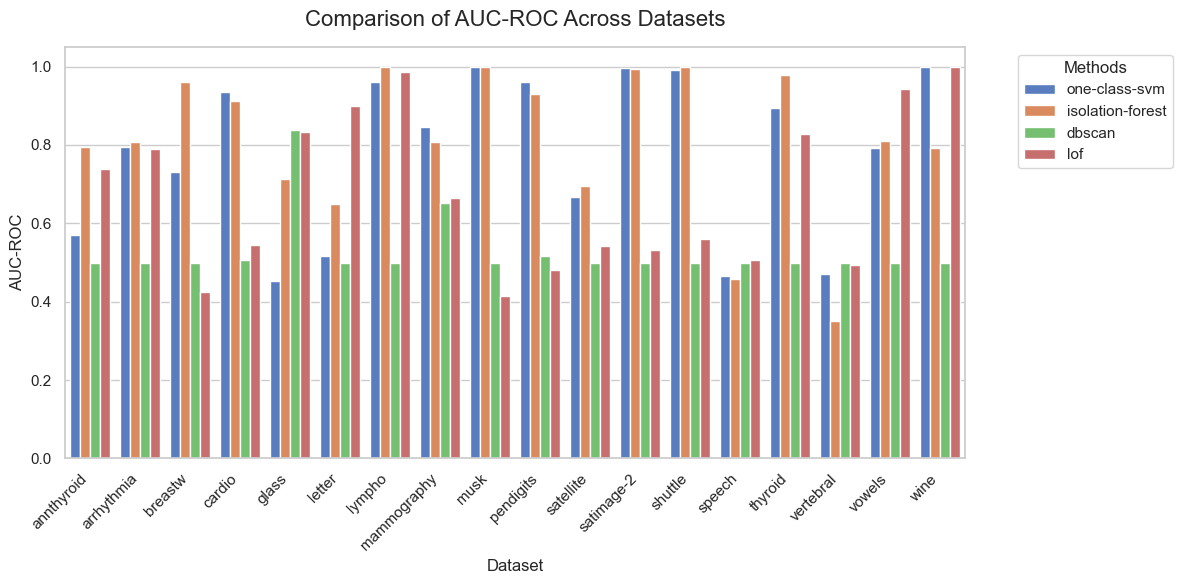

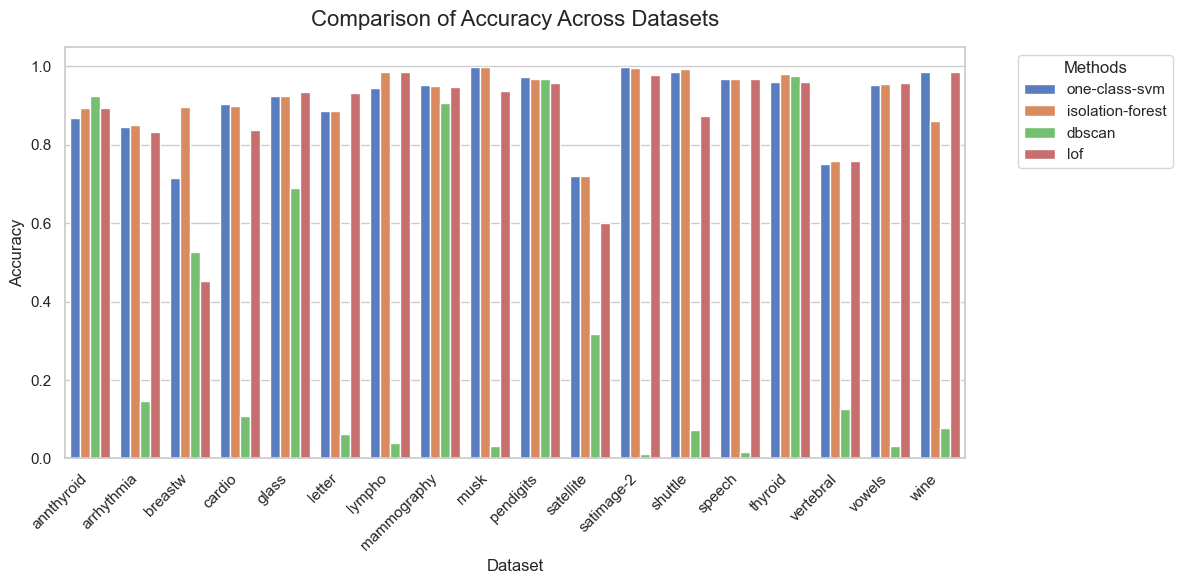

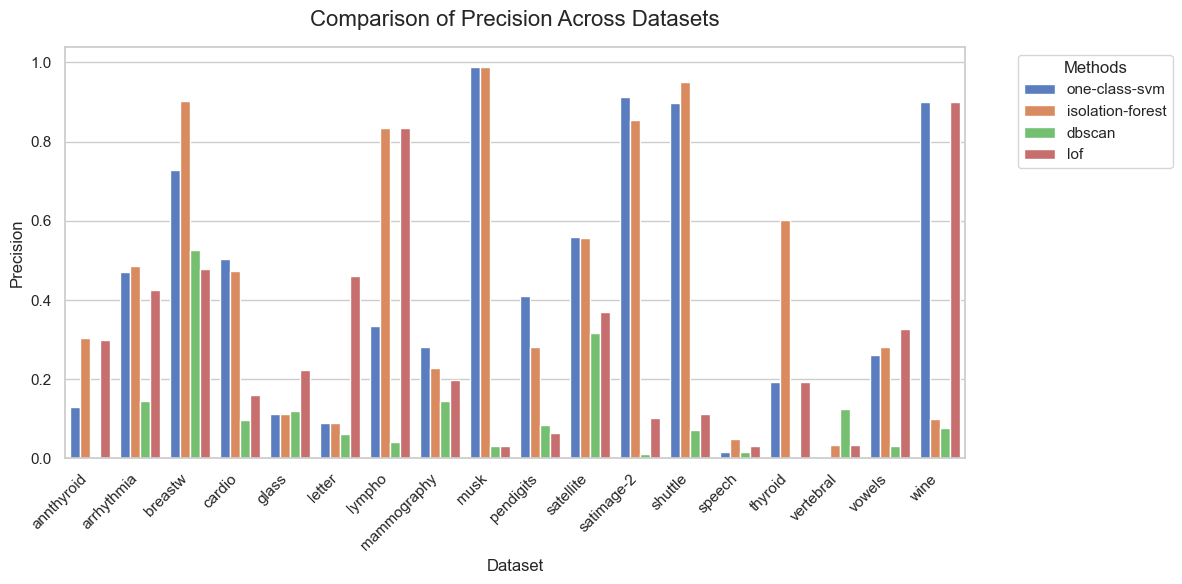

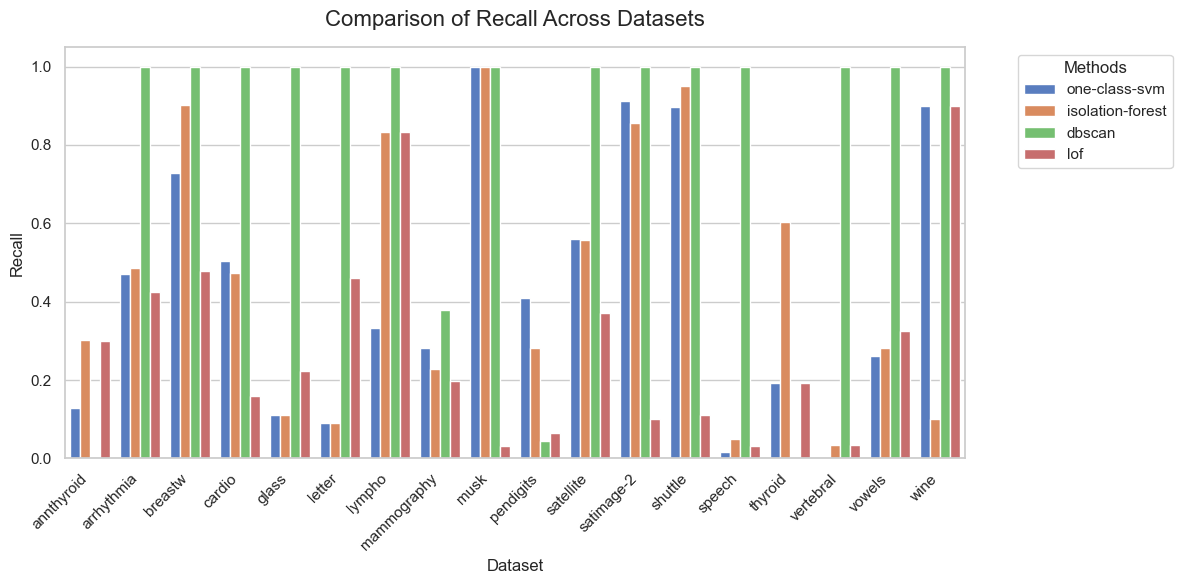

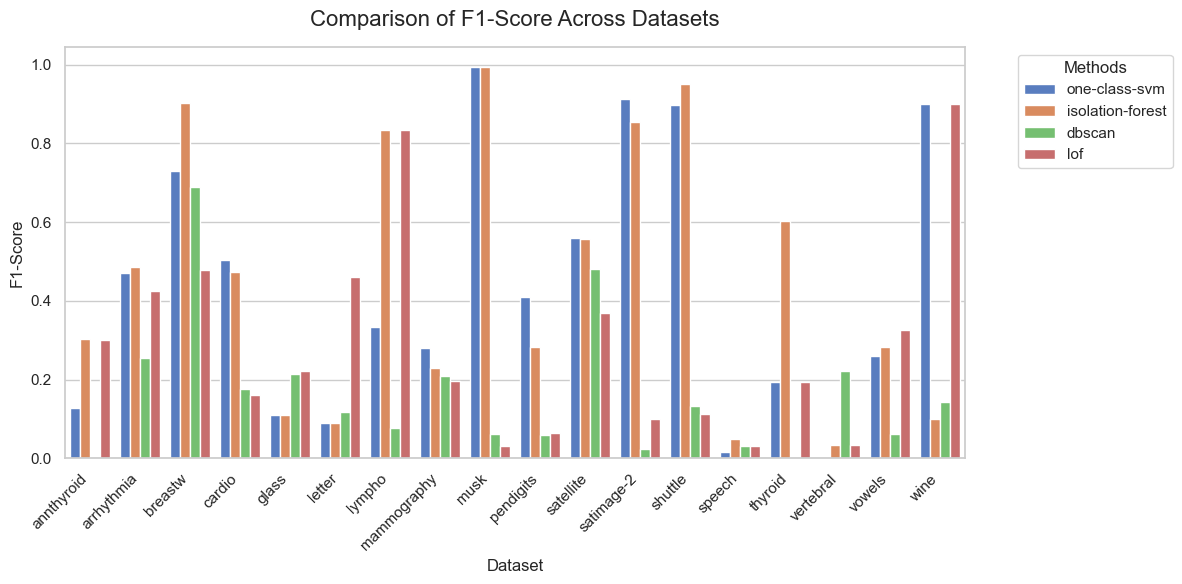

In [15]:
for metric in default_results['lof']['glass'].keys():
    plot_metric_results(default_results,metric)

# Hyperparameter influence

In [16]:

param_grids = {
    "one-class-svm": {
        "nu": [0.01, 0.05, 0.1, 0.2],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
        "shrinking": [True, False]
    },
    "isolation-forest": {
        "n_estimators": [50, 100, 200],
        "max_features": [0.5, 1.0]
    },
    "lof": {
        "n_neighbors": [5, 15, 20, 50],
        "metric": ["euclidean", "manhattan"]
    }
}

hyperparam_results = {
    method: {dataset: [] for dataset in all_datasets.keys()}
    for method in ["one-class-svm", "isolation-forest", "lof"]
}

for dataset_name, data in all_datasets.items():
    X = data["X"]
    y = data["y"]
    # Mean of binary outlier vector yields the contamination ratio
    contamination_rate = float(np.mean(y))

    grid_svm = param_grids["one-class-svm"]
    keys, values = zip(*grid_svm.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        model = OneClassSVM(**params)
        model.fit(X)
        scores = get_unified_outlier_scores(model, X, "one-class-svm")
        preds = threshold_by_top_k(scores, contamination_rate)
        metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

        hyperparam_results["one-class-svm"][dataset_name].append({**params, **metrics})

    grid_if = param_grids["isolation-forest"]
    keys, values = zip(*grid_if.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        model = IsolationForest(**params, random_state=42)
        model.fit(X)
        scores = get_unified_outlier_scores(model, X, "isolation-forest")
        preds = threshold_by_top_k(scores, contamination_rate)
        metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

        hyperparam_results["isolation-forest"][dataset_name].append({**params, **metrics})

    grid_lof = param_grids["lof"]
    keys, values = zip(*grid_lof.items())
    for v in itertools.product(*values):
        params = dict(zip(keys, v))
        if params["n_neighbors"] < len(X):
            model = LocalOutlierFactor(n_neighbors=params["n_neighbors"], metric=params["metric"])
            model.fit(X)
            scores = get_unified_outlier_scores(model, X, "lof")
            preds = threshold_by_top_k(scores, contamination_rate)
            metrics, _ = compute_evaluation_metrics(y, scores, y_pred=preds)

            hyperparam_results["lof"][dataset_name].append({**params, **metrics})
    print(f"dataset {dataset_name} finished")
print("Continuous-score methods tuning completed successfully.")

dataset annthyroid finished
dataset arrhythmia finished
dataset breastw finished
dataset cardio finished
dataset glass finished
dataset letter finished
dataset lympho finished
dataset mammography finished
dataset musk finished
dataset pendigits finished
dataset satellite finished
dataset satimage-2 finished
dataset shuttle finished
dataset speech finished
dataset thyroid finished
dataset vertebral finished
dataset vowels finished
dataset wine finished
Continuous-score methods tuning completed successfully.


In [22]:
#checkpoint saving
# import joblib
# joblib.dump(hyperparam_results,"result_dicts/hyperparam_optimization_metric_dict.joblib")

['result_dicts/hyperparam_optimization_metric_dict.joblib']

Analyzing sensitivity using target metric: 'F1-Score'

### HYPERPARAMETER SENSITIVITY SUMMARY PER ALGORITHM ###
| method           |   mean |    std |    min |    max |   range |
|:-----------------|-------:|-------:|-------:|-------:|--------:|
| isolation-forest | 0.4537 | 0.3274 | 0.0164 | 1      |  0.9836 |
| lof              | 0.2684 | 0.2222 | 0      | 0.9    |  0.9    |
| one-class-svm    | 0.1748 | 0.1875 | 0      | 0.9275 |  0.9275 |


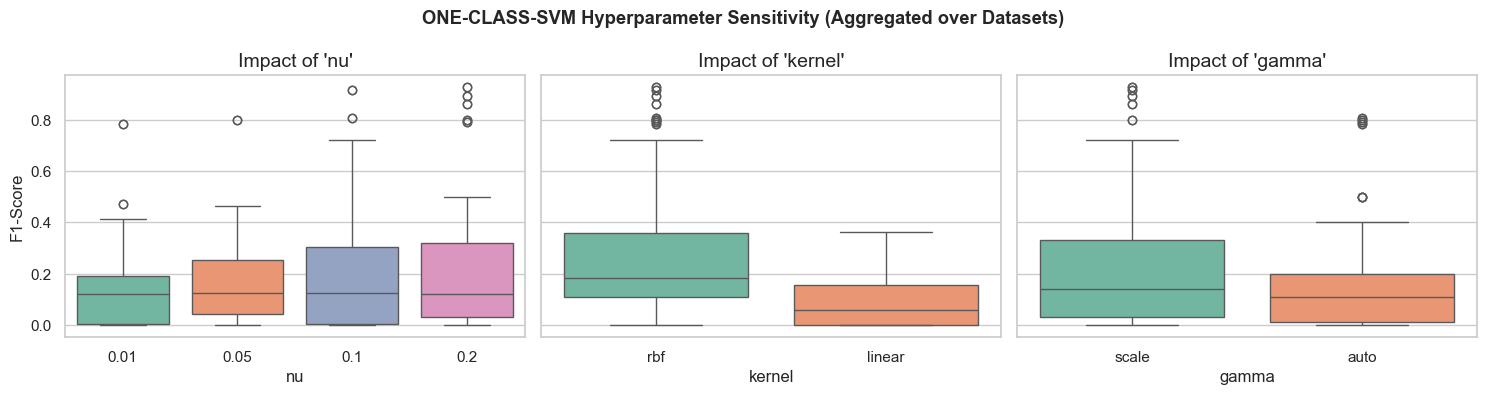

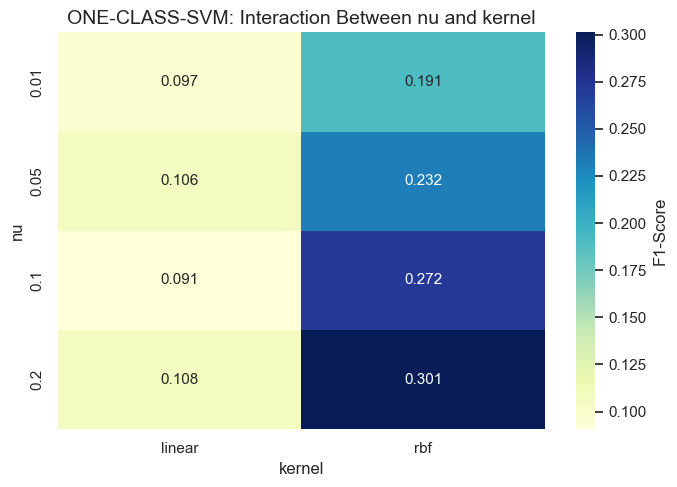

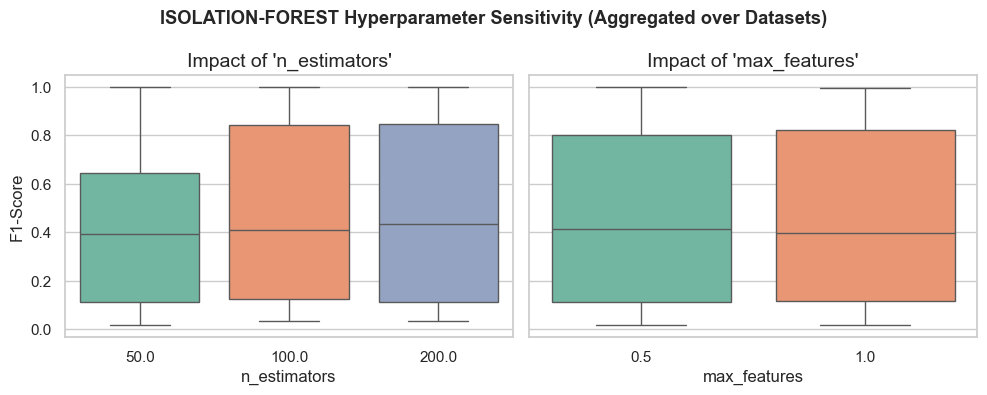

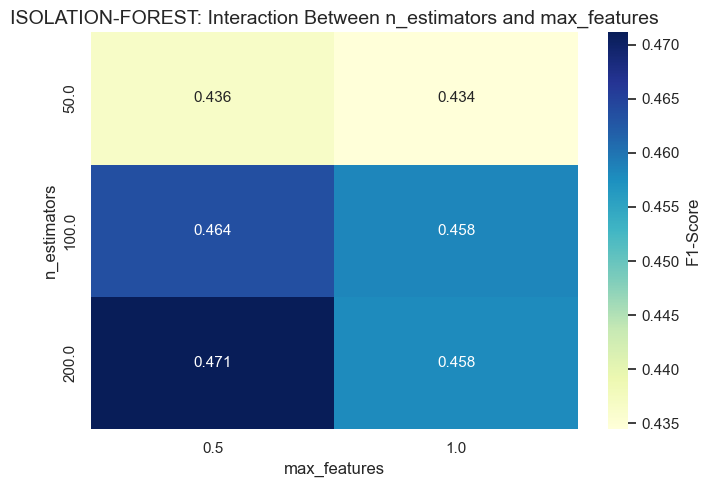

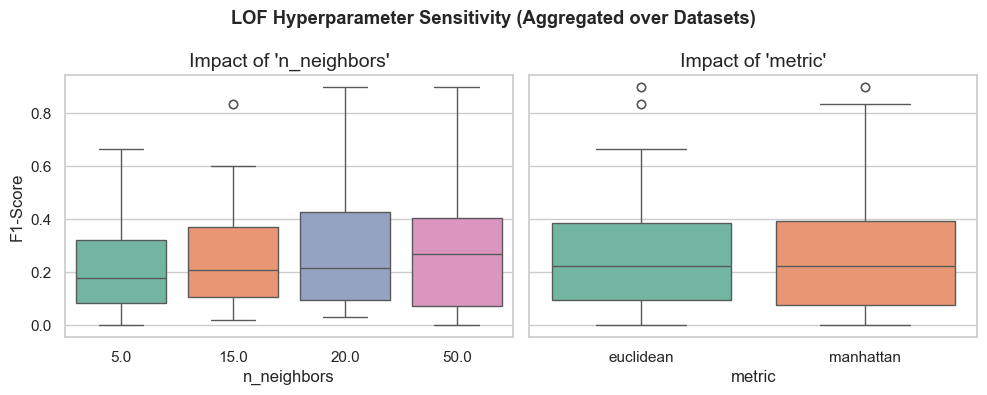

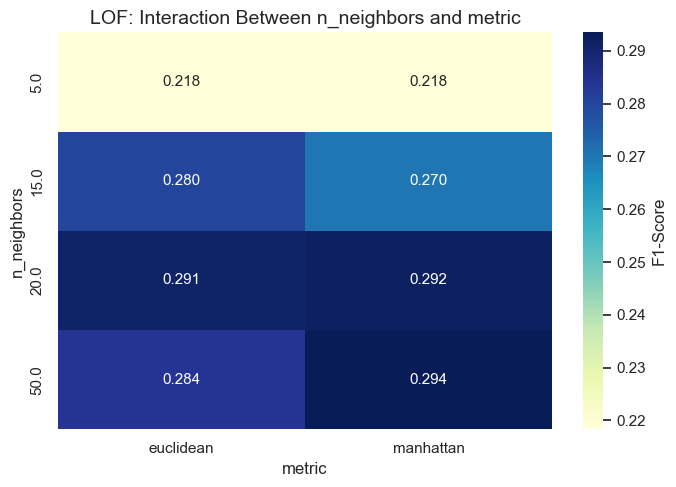

In [20]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})



# 1. Flatten data
df_results = extract_hyperparam_results_to_df(hyperparam_results)

metric_of_interest = 'F1-Score'

# If metric doesn't exist yet in your real data, fall back to a generic name
if metric_of_interest not in df_results.columns:
    # Pick the last column as a fallback metric assumption
    metric_of_interest = df_results.columns[-1]

print(f"Analyzing sensitivity using target metric: '{metric_of_interest}'")

## 1. Aggregated Statistical Table (Sensitivity Analysis)

# We calculate the variance/range of performance across hyperparameter changes per algorithm.
# High standard deviation or a wide range implies high sensitivity.
print("\n### HYPERPARAMETER SENSITIVITY SUMMARY PER ALGORITHM ###")
summary_stats = df_results.groupby('method')[metric_of_interest].agg(['mean', 'std', 'min', 'max'])
summary_stats['range'] = summary_stats['max'] - summary_stats['min']
print(summary_stats.round(4).to_markdown())

## 2. Visualization Code

# Map out the exact hyperparameters we tested for each model to isolate them
model_params = {
    "one-class-svm": ["nu", "kernel", "gamma"],
    "isolation-forest": ["n_estimators", "max_features"],
    "lof": ["n_neighbors", "metric"]
}

for method, params in model_params.items():
    df_method = df_results[df_results['method'] == method]

    if df_method.empty:
        continue

    num_params = len(params)
    fig, axes = plt.subplots(1, num_params, figsize=(5 * num_params, 4), sharey=True)
    if num_params == 1:
        axes = [axes]

    fig.suptitle(f'{method.upper()} Hyperparameter Sensitivity (Aggregated over Datasets)', weight='bold')

    for i, param in enumerate(params):
        # Boxplot shows both the stability (spread) and overall performance trend
        sns.boxplot(
            data=df_method,
            x=param,
            y=metric_of_interest,
            ax=axes[i],
            palette="Set2"
        )
        axes[i].set_title(f"Impact of '{param}'")
        axes[i].set_xlabel(param)
        if i == 0:
            axes[i].set_ylabel(metric_of_interest)
        else:
            axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()

    # --- Interaction Heatmap Example (e.g., for Isolation Forest or LOF) ---
    if num_params >= 2:
        plt.figure(figsize=(7, 5))
        # Pivot table to find mean performance across the first two parameters
        piv = df_method.pivot_table(
            index=params[0],
            columns=params[1],
            values=metric_of_interest,
            aggfunc='mean'
        )
        sns.heatmap(piv, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': metric_of_interest})
        plt.title(f"{method.upper()}: Interaction Between {params[0]} and {params[1]}")
        plt.tight_layout()
        plt.show()

In [17]:
print(hyperparam_results)

{'one-class-svm': {'annthyroid': [{'nu': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': True, 'AUC-ROC': 0.6660937958985093, 'Accuracy': 0.886434437836307, 'Precision': 0.24906367041198502, 'Recall': 0.24906367041198502, 'F1-Score': 0.24906367041198502}, {'nu': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': False, 'AUC-ROC': 0.6660937958985093, 'Accuracy': 0.886434437836307, 'Precision': 0.24906367041198502, 'Recall': 0.24906367041198502, 'F1-Score': 0.24906367041198502}, {'nu': 0.01, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': True, 'AUC-ROC': 0.5640800561797753, 'Accuracy': 0.8677428490512603, 'Precision': 0.1254681647940075, 'Recall': 0.1254681647940075, 'F1-Score': 0.1254681647940075}, {'nu': 0.01, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': False, 'AUC-ROC': 0.5640800561797753, 'Accuracy': 0.8677428490512603, 'Precision': 0.1254681647940075, 'Recall': 0.1254681647940075, 'F1-Score': 0.1254681647940075}, {'nu': 0.01, 'kernel': 'linear', 'gamma': 'scale', 'shrink